In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [17]:
try:
    # enconding = 'latin1' 
    # enconding = 'IBM860'
    # enconding = 'iso-8859-1' (pega quase sempre)
    df = pd.read_csv('03.BaseDPEvolucaoMensalCisp.csv',
                     encoding='iso-8859-1', sep=';')
    # print(df.head())
    print(df.columns)
except Exception as e:
    print(f'Erro: {e}')
    exit()

Index(['cisp', 'mes', 'ano', 'mes_ano', 'aisp', 'risp', 'munic', 'mcirc',
       'regiao', 'hom_doloso', 'lesao_corp_morte', 'latrocinio', 'cvli',
       'hom_por_interv_policial', 'letalidade_violenta', 'tentat_hom',
       'lesao_corp_dolosa', 'estupro', 'hom_culposo', 'lesao_corp_culposa',
       'roubo_transeunte', 'roubo_celular', 'roubo_em_coletivo', 'roubo_rua',
       'roubo_veiculo', 'roubo_carga', 'roubo_comercio', 'roubo_residencia',
       'roubo_banco', 'roubo_cx_eletronico', 'roubo_conducao_saque',
       'roubo_apos_saque', 'roubo_bicicleta', 'outros_roubos', 'total_roubos',
       'furto_veiculos', 'furto_transeunte', 'furto_coletivo', 'furto_celular',
       'furto_bicicleta', 'outros_furtos', 'total_furtos', 'sequestro',
       'extorsao', 'sequestro_relampago', 'estelionato', 'apreensao_drogas',
       'posse_drogas', 'trafico_drogas', 'apreensao_drogas_sem_autor',
       'recuperacao_veiculos', 'apf', 'aaapai', 'cmp', 'cmba', 'ameaca',
       'pessoas_desaparecidas'

In [18]:
# filtrar
df_recuperacao_veiculos = df[['munic', 'recuperacao_veiculos']]
 

# agrupar por municipio
df_recuperacao_veiculos = \
df_recuperacao_veiculos.groupby('munic').sum()\
.reset_index().sort_values(by='recuperacao_veiculos', ascending=False)
df_recuperacao_veiculos
print(df_recuperacao_veiculos.head(10))

                    munic  recuperacao_veiculos
68         Rio de Janeiro                269057
23        Duque de Caxias                 42959
78            São Gonçalo                 39574
81     São João de Meriti                 19341
50            Nova Iguaçu                 17217
48                Niterói                 15417
6            Belford Roxo                 14164
13  Campos dos Goytacazes                  5334
47              Nilópolis                  5257
43               Mesquita                  5000


In [19]:
# Existe grande diferença entre os primeiros municípios do ranking?
# Resposta: sim pois as medidas centrais e de dispersão estão  afastadas


# iloc -> pega 'n' linhas -> indice
top = df_recuperacao_veiculos.iloc[0:10]
top

# Medidas de Tendencia Centrais

# Medidas de Tendencia Centrais

coluna_alvo = 'recuperacao_veiculos'
media_valor = df_recuperacao_veiculos[coluna_alvo].mean()
recuperacao_minima = df_recuperacao_veiculos[coluna_alvo].min()
recuperacao_maxima = df_recuperacao_veiculos[coluna_alvo].max()
recuperacao_mediana = df_recuperacao_veiculos[coluna_alvo].median()



print(f'Média: {media_valor:,.2f}')
print(f'Valor Mínimo: {recuperacao_minima:,.2f}')
print(f'Valor Mximo: {recuperacao_maxima:,.2f}')
print(f'Valor Mximo: {recuperacao_mediana:,.2f}')

# Medidas de Dispersão

# 1. Amplitude
amplitude = recuperacao_maxima - recuperacao_minima
print(f'Amplitude: {recuperacao_mediana:,.2f}')





Média: 5,460.99
Valor Mínimo: 24.00
Valor Mximo: 269,057.00
Valor Mximo: 370.50
Amplitude: 370.50


In [20]:
#Compare com o ranking de roubo de veículos. O município que mais tem roubos também lidera em recuperações?
# Sim, pois o Rio de Janeiro lidera o número de roubo e de recuperação

# filtrar
df_roubo_veiculos = df[['munic', 'roubo_veiculo']]
# print(df_roubo_veiculos.head())

# agrupar por municipio
df_roubo_veiculos = \
df_roubo_veiculos.groupby('munic').sum()\
.reset_index().sort_values(by='roubo_veiculo', ascending=False)
df_roubo_veiculos


,munic,roubo_veiculo
68,Rio de Janeiro,372584
23,Duque de Caxias,62574
78,São Gonçalo,52539
50,Nova Iguaçu,40235
81,São João de Meriti,30151
...,...,...
66,Rio das Flores,8
58,Porciúncula,7
46,Natividade;Varre-Sai,6
45,Miracema,6


In [21]:
# filtrar (Análise por ano)
df_recuperacao_veiculos_ano = df[['ano', 'recuperacao_veiculos']]


# agrupar por municipio
df_recuperacao_veiculos_ano = \
df_recuperacao_veiculos_ano.groupby('ano').sum()\
.reset_index().sort_values(by='recuperacao_veiculos', ascending=False)

df_recuperacao_veiculos_ano



,ano,recuperacao_veiculos
14,2017,37630
15,2018,36448
0,2003,29947
13,2016,28690
16,2019,26863
1,2004,26522
2,2005,26332
3,2006,26073
11,2014,25227
4,2007,24452


In [ ]:
# Qual foi o ano qual maior número de recuperação de veiculo?
# Resposta: 2017
# Existe alguma tendencia de crescimento ou queda ao longo do ano?
# Sim, existe uma tendência a queda de recuperação de veiculo ao longo do tempo



In [ ]:
# Esse comportamento acompanha o crescimento ou queda dos roubos de veículos?
# Resposta : Sim

df_roubo_veiculos_ano = df[['ano', 'roubo_veiculo']]

# agrupar por municipio
df_roubo_veiculos_ano = \
df_roubo_veiculos_ano.groupby('ano').sum()\
.reset_index().sort_values(by='roubo_veiculo', ascending=False)

df_roubo_veiculos_ano




,ano,roubo_veiculo
14,2017,54366
15,2018,52097
13,2016,41696
16,2019,39749
3,2006,34324
0,2003,33531
2,2005,32690
11,2014,32651
1,2004,32408
4,2007,31490


<BarContainer object of 22 artists>

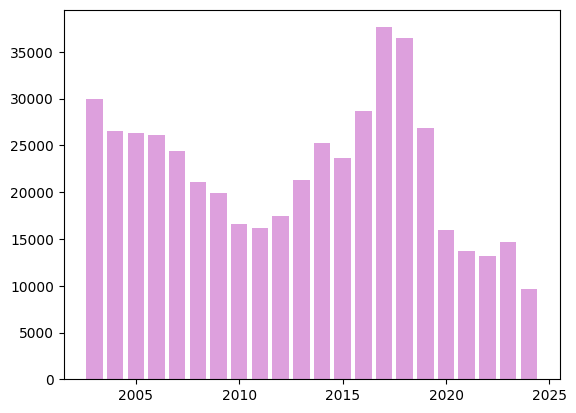

In [ ]:
# 3. Visualização
# Crie um gráfico de barras mostrando o total de veículos recuperados por ano.

plt.bar(df_recuperacao_veiculos_ano['ano'], df_recuperacao_veiculos_ano['recuperacao_veiculos'], color = 'plum' \
'')

<function matplotlib.pyplot.boxplot(x: 'ArrayLike | Sequence[ArrayLike]', *, notch: 'bool | None' = None, sym: 'str | None' = None, vert: 'bool | None' = None, orientation: "Literal['vertical', 'horizontal']" = 'vertical', whis: 'float | tuple[float, float] | None' = None, positions: 'ArrayLike | None' = None, widths: 'float | ArrayLike | None' = None, patch_artist: 'bool | None' = None, bootstrap: 'int | None' = None, usermedians: 'ArrayLike | None' = None, conf_intervals: 'ArrayLike | None' = None, meanline: 'bool | None' = None, showmeans: 'bool | None' = None, showcaps: 'bool | None' = None, showbox: 'bool | None' = None, showfliers: 'bool | None' = None, boxprops: 'dict[str, Any] | None' = None, tick_labels: 'Sequence[str] | None' = None, flierprops: 'dict[str, Any] | None' = None, medianprops: 'dict[str, Any] | None' = None, meanprops: 'dict[str, Any] | None' = None, capprops: 'dict[str, Any] | None' = None, whiskerprops: 'dict[str, Any] | None' = None, manage_ticks: 'bool' = Tru

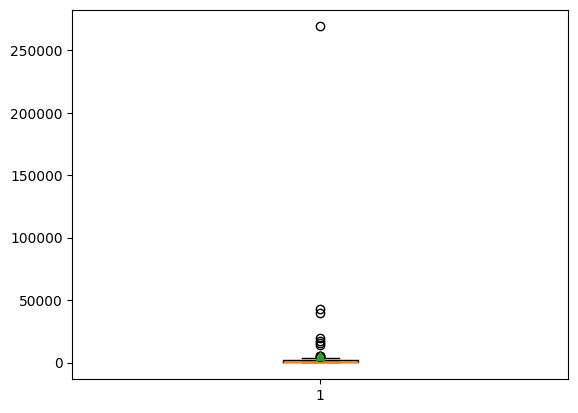

In [ ]:
#O gráfico mostra algum pico específico em determinado ano?
# Sim , em 2017 e 2018

#Existe algum ano com queda significativa nas recuperações?
# Sim, em 2024

#O que pode explicar essas variações? (hipóteses)
# Como o mumero de roubo está tendendo a queda, consequentemente a diminui o numero de veículos recuperados.

#Identifique possíveis outliers (municípios com recuperação muito acima ou abaixo da média).
# Sim, existe um outliers acima de 250000.


plt.boxplot(df_recuperacao_veiculos['recuperacao_veiculos'], vert=True, showmeans=True, showfliers=True)

plt.boxplot
